## Simple Molecular Dynamics Simulation

**Molecular dynamics (MD)** is a computational simulation method used to study how a system of interacting particles, such as atoms or molecules, changes over time. By numerically solving the equations of motion (most commonly Newton’s equations), MD generates trajectories that describe the positions and velocities of particles at successive time steps. These trajectories sample many microscopic configurations (microstates) of the system. Based on the **ergodic hypothesis**, time averages calculated from a sufficiently long simulation can be related to ensemble averages, allowing macroscopic properties such as energy, temperature, diffusion, and structural behavior to be determined.

When given initial positions `r(t)`, velocities `v(t)`, and accelerations `a(t)`, the trajectories can be calculated using a so-called **Velocity-Verlet integrator** with timestep $\delta t$. This algorithm looks like:

\begin{align}
v(t+\delta t/2) &= v(t) + a(t) \cdot \frac{\delta t}{2} \\
r(t+\delta t) &= r(t) + v(t+\delta t/2) \cdot \delta t \\
\text{get } f(t+\delta t) &= f(r(t+\delta t))\qquad
(\text{so you can get } a(t+\delta t))\\
v(t+\delta t) &= v(t+\delta t/2) + a(t+\delta t) \cdot \frac{\delta t}{2}\\
\end{align}

First, the velocity is advanced by half a time step using the current acceleration (1). Next, the new position is calculated using this half-step velocity (2). From the updated position the new forces are determined, from which the new acceleration is computed using Newton's second law ($F=ma$) (3). Finally, the velocity is completed by applying the second half-step update with the new acceleration (4).

In this MD simulation, a simple implementation of the Velocity-Verlet algorithm is used to generate the trajectories of a system containing 10 argon atoms. The initial atomic coordinates are read from a provided XYZ file, while the required physical constants are obtained from the SciPy constants library.

In [1]:
from pyscf import gto
import scipy.constants as sc

# Build a PySCF molecule object from an XYZ file
mol = gto.M(
    atom = 'Ar10.xyz',
    basis='6-31g*',
    charge=0,
    spin=0
)
print("Number of atoms: ", mol.natm)

# Get atomic coordinates (in Bohr units by default)
coords = mol.atom_coords() 
print("Coordinates with shape",coords.shape,":\n",coords)

# Get atomic masses (in amu) and convert to electron mass units
amu2me = sc.physical_constants['atomic mass constant'][0] / sc.electron_mass # amu to electron mass
masses = mol.atom_mass_list(isotope_avg=True)*amu2me

print("Atom mass list of shape", masses.shape, "\n",masses)

Number of atoms:  10
Coordinates with shape (10, 3) :
 [[ 1.25632583  7.05121068  1.3526773 ]
 [ 0.1744992   7.73412557  5.85718723]
 [ 7.07793707  1.3504153   0.02216082]
 [ 5.19119672  6.40215023 -2.26025228]
 [ 0.24132747 12.33452209  0.25860146]
 [ 1.87002195 13.3567222   4.54918872]
 [11.83779058  4.30611136 -0.16523765]
 [ 6.18415898 10.7816132   1.20043151]
 [ 4.24214035  3.17114374  2.30739717]
 [ 1.0572035   1.14633243  0.10626119]]
Atom mass list of shape (10,) 
 [72820.74925002 72820.74925002 72820.74925002 72820.74925002
 72820.74925002 72820.74925002 72820.74925002 72820.74925002
 72820.74925002 72820.74925002]


MD simulations can become computationally expensive because the potential energy and forces must be evaluated at every time step. For this reason, many simulations rely on classical Force Fields rather than explicit quantum-chemical calculations, although ab initio MD is also possible.

In this example, the energies will be computed using the Lennard-Jones potential, a simple pairwise potential between all atoms in the system:

\begin{equation*}
E_{pot} = 4 \epsilon \sum_{i<j} \left[ \left( \frac{\sigma}{r_{ij}} \right)^{12} - \left( \frac{\sigma}{r_{ij}} \right)^6 \right]
\end{equation*}

where $i$ and $j$ are two of the system's particles, $\epsilon$ and $\sigma$ the characteristic parameters of the potential, and $r_{ij}$ is the distance between particle $i$ and $j$. A function that calculates the potential energy of a system according to the Lenard-Jones potential was implemented.

In [2]:
import numpy as np
epsilon = 0.0015936015 # in Hartree
sigma = 3.77945225 # in Bohr

def lennard_jones_pot(coords):

    sum_res = 0.0
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            r = np.linalg.norm(coords[i] - coords[j])
            sum_term = (sigma / r)**12 - (sigma / r)**6
            sum_res += sum_term
            
    Epot = 4 * epsilon * sum_res
    
    return Epot # in a.u. (Hartree)

e_pot = lennard_jones_pot(coords)
print(f"Lennard-Jones Energy is {e_pot} Hartree")

Lennard-Jones Energy is -0.01311584476536432 Hartree


The force for atom $i$ in the direction $\alpha$ is then given as the derivative of the Lennard-Jones potential:

\begin{equation*}
F_{i,\alpha} = - \frac{\partial E}{\partial R_{i,\alpha}} = 4 \epsilon \sum_{i≠j} \left[ 12 \frac{\sigma^{12}}{r_{ij}^{14}} - 6 \frac{\sigma^6}{r_{ij}^8} \right] \left(R_{i,\alpha}-R_{j,\alpha} \right)
\end{equation*}

where $R_{i,\alpha}$ is the position of atom $i$ in the $\alpha$ direction ($\alpha=x, y, z$). 

The function below calculates the forces according to the Lennard-Jones potential for every atom in every direction and returns an $N_{at} \times 3$ NumPy array. Making use of the Newton's third law that states $F_{i,\alpha} = -F_{j,\alpha}$, the calculation can be made efficient by looping over only half of the atom pairs.

In [3]:
def lennard_jones_forces(coords):

    forces = np.zeros((len(coords), 3))
    
    for i in range(len(coords)):
        for j in range(i):
            r_vec = coords[i] - coords[j]
            r = np.linalg.norm(r_vec)
            F = 12 * sigma**12 / r**14 - 6 * sigma**6 / r**8

            fij = F * r_vec

            forces[i] += fij
            forces[j] -= fij
    
    return 4 * epsilon * forces

forces = lennard_jones_forces(coords)
print("Lennard-Jones Forces in Hartree/Bohr:")
print(forces)

Lennard-Jones Forces in Hartree/Bohr:
[[ 9.37139327e-04 -1.49835971e-04  5.61243551e-04]
 [ 4.47228628e-04  1.50482416e-04 -1.24334524e-03]
 [ 1.10432697e-03 -8.89005925e-05 -1.09936569e-03]
 [-3.56566711e-04 -2.43148757e-04  1.38186798e-03]
 [ 7.59090220e-04 -5.26483078e-04  1.14693409e-03]
 [-2.11792248e-04 -8.03110636e-04 -1.09515327e-03]
 [-6.09935510e-04 -2.29567565e-04  1.02604192e-05]
 [-8.51565674e-04 -4.49845068e-04 -1.21623303e-04]
 [-2.07456541e-03  1.60525767e-03  1.15871719e-04]
 [ 8.56640415e-04  7.35151578e-04  3.43309747e-04]]


From the NumPy array of forces above the accelerations can be calculated using the Newton's second law.

In [4]:
def newton_acceleration(masses,forces):
    acceleration = np.zeros_like(forces)
    for m in range(len(masses)):
        acceleration[m,:] = forces[m] / masses[m]
    return acceleration

acc = newton_acceleration(masses, forces)
print("Newtonian Accelerations in Hartree/(Bohr*me)")
print(acc)

Newtonian Accelerations in Hartree/(Bohr*me)
[[ 1.28691250e-08 -2.05759996e-09  7.70719275e-09]
 [ 6.14149995e-09  2.06647718e-09 -1.70740518e-08]
 [ 1.51650042e-08 -1.22081403e-09 -1.50968741e-08]
 [-4.89649879e-09 -3.33900378e-09  1.89762944e-08]
 [ 1.04240924e-08 -7.22984978e-09  1.57501001e-08]
 [-2.90840523e-09 -1.10285962e-08 -1.50390278e-08]
 [-8.37584777e-09 -3.15250210e-09  1.40899665e-10]
 [-1.16939977e-08 -6.17742982e-09 -1.67017374e-09]
 [-2.84886579e-08  2.20439599e-08  1.59119097e-09]
 [ 1.17636858e-08  1.00953586e-08  4.71444952e-09]]


The following function performs a MD simulation using the Velocity-Verlet algorithm as described above. Starting from an initial set of atomic coordinates, the positions and velocities of the particles are propagated over a specified number of time steps according to Newton’s equations of motion. During the simulation, the potential energy is recorded at every step, while atomic coordinates are saved periodically to store the trajectory. The resulting trajectory is written to a compressed NumPy file (`md.npz`) for later analysis or visualization. 

Below, a simulation of 50000 MD steps with a timestep of 0.4 a.u. (about 0.01 fs) is run for the system of 10 argon atoms. This calculation can take up to a couple of minutes.

In [5]:
def velocity_verlet(coordinates, masses, nsteps, timestep):

    # Initialize arrays to store trajectory, velocities, forces, and energies
    coords = np.copy(coordinates)  
    coords_saved = np.zeros((int(nsteps/50), len(coords), 3))  
    velocities = np.zeros_like(coordinates) 
    forces = np.zeros_like(coordinates)  
    energies = np.zeros((nsteps))
    
    # Calculate initial values for potential energy, forces, and acceleration
    energies[0] = lennard_jones_pot(coords)
    forces = lennard_jones_forces(coords)
    acceleration = newton_acceleration(masses,forces)
    
    # Main MD loop
    for step in range(1, nsteps):
        
        velocities += acceleration * timestep/2  # First half-step velocity update
        coords += velocities * timestep  # Update atomic positions
        
        forces = lennard_jones_forces(coords)  # Compute new forces from updated coordinates
        acceleration = newton_acceleration(masses,forces)  # Compute new accelerations

        velocities += acceleration * timestep/2  # Second half-step velocity update
        energies[step] = lennard_jones_pot(coords)  # Store potential energy for current step

        # Save coordinates every 50 steps
        if step % 50 == 0:
            coords_saved[int(step/50)] = coords
        # Print progress every 5000 steps
        if step % 5000 == 0:
            print(f"Step {step} done")
    
    # Save trajectory to a compressed NumPy file
    np.savez_compressed('md.npz',trajectory=coords_saved)
    return coords_saved, velocities, forces, energies

# Run 50000 MD steps with a timestep of 0.4 a.u.
coords_md, velo_md, forces_md, energies_md = velocity_verlet(coords, masses, nsteps=50000, timestep=0.4)

print(energies_md)

Step 5000 done
Step 10000 done
Step 15000 done
Step 20000 done
Step 25000 done
Step 30000 done
Step 35000 done
Step 40000 done
Step 45000 done
[-0.01311584 -0.01311584 -0.01311584 ... -0.02067977 -0.02067821
 -0.02067664]


The energies obtained from the MD simulation are plotted as a function of the number of MD steps.

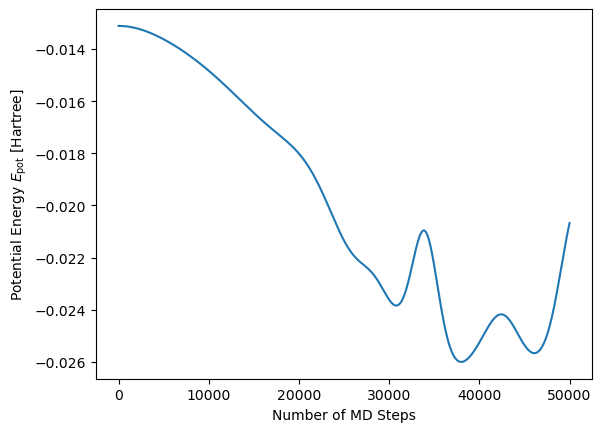

In [6]:
import matplotlib.pyplot as plt

plt.plot(energies_md)

plt.xlabel("Number of MD Steps")
plt.ylabel(r"Potential Energy $E_\text{pot}$ [Hartree]")

plt.show()

The plot of potential energy vs MD steps shows a steady decrease in potential energy until about 30000 steps, after which the potential energy fluctuates. The monotonic decrease indicates the cluster of atoms is relaxing from the initial configuration toward lower-energy arrangements, finding deeper minima on the potential energy surface. After about 30000 steps the system has sampled new configurations, and energy barriers are being crossed, producing the larger fluctuations in potential energy.

The trajectory from the MD simulation stored in the .npz file is visualized using the `py3Dmol` package. 

In [ ]:
import py3Dmol

def visualize_trajectory(filename):
    """
    Visualize the molecular dynamics trajectory stored in a .npz file.
    """
    
    import mdtraj as md
    import scipy.constants as sc
    import numpy as np
    import os
    try:
        data = np.load(filename)
        traj_coords = data['trajectory']
    except FileNotFoundError:
        print(f"Error: {filename} file not found. Please run the MD simulation first.")
        return None

    # Convert coordinates from Bohr to nm
    a0 = sc.physical_constants['Bohr radius'][0]
    ang2bohr =   1.0e-10 / a0
    coords_nm = traj_coords / (ang2bohr * 10.0) 
    
    # Create trajectory object
    topology = md.load('Ar10.pdb').topology
    traj = md.Trajectory(coords_nm, topology)

    # Save trajectory to PDB
    temp_file = os.path.splitext(filename)[0] +"_temp.pdb"
    traj.save_pdb(temp_file)
    
    # Create 3Dmol viewer
    view = py3Dmol.view(width=800, height=600)
    with open(temp_file, 'r') as f:
        pdb_string = f.read()
    view.addModelsAsFrames(pdb_string, 'pdb')
    
    os.remove(temp_file)  # Clean up temporary file
    
    # Set visualization style
    view.setStyle({'stick': {'radius': 0.2}, 'sphere': {'scale': 0.3}})
    view.zoomTo()
    view.animate({'loop': 'forward', 'interval': 1})
    view.show()

# Visualize the trajectory from the MD simulation of argon atoms
visualize_trajectory('md.npz')

The visualisation shows atoms moving relative to one another, whereby interatomic distances decrease and increase, and the visualization’s distance-based “bonds” appear to form and break over time. In this simulation, kinetic energy and thus instantaneous temperature and velocity information are missing. The first law of thermodynamics is not fulfilled as the energy of the simulation is not controlled.

To fix the issues encountered in the previous simulation, a thermostat is introduced to regulate the system's temperature. The most straightforward way to do this is by rescaling the velocities of the atoms, adjusting their kinetic energy to match the target temperature.

Below is a function that computes the system's total kinetic energy based on the velocities and masses of the atoms.
\begin{equation*}
E_{kin} = \frac{1}{2} \sum_{i=1}^{N_{at}} m_i v_i^2
\end{equation*}

In [8]:
def kin_energy(masses, velocities):
    ke = 0.0
    for i in range(len(masses)):
        v2 = np.dot(velocities[i], velocities[i]) 
        ke += 0.5 * masses[i] * v2
    return ke

e_kin = kin_energy(masses,velo_md)

print(f"Kinetic energy at the end of the last simulation: {e_kin} Hartree.")

Kinetic energy at the end of the last simulation: 0.007560797715231934 Hartree.


The function below calculates the temperature of the system given a certain kinetic energy.

\begin{equation*}
T = \frac{2}{3} \frac{E_{kin}}{k_B N_{at}}
\end{equation*}

In [9]:
kB_au = sc.Boltzmann / sc.physical_constants['Hartree energy'][0]  # Boltzmann constant in Hartree/K

def temp_from_ekin(e_kin, N_at):
    temp = 2/3 * e_kin / (kB_au * N_at)
    return temp

temp = temp_from_ekin(e_kin, len(masses))
print(f"Temperature at the end of the last simulation: {temp} K.")

Temperature at the end of the last simulation: 159.16740573768618 K.


In a realistic scenario, atoms are never perfectly stationary at the beginning of a simulation. To better mimic physical reality, initial velocities must be assigned to the particles. This can be accomplished using the Maxwell-Boltzmann distribution, which describes particle speeds in an ideal gas.

Mathematically, this is represented as a Gaussian (normal) distribution centered at a net velocity of zero, with a standard deviation defined as:

\begin{equation*}
\sigma = \sqrt{\frac{k_B T}{m}}
\end{equation*}

The Maxwell-Boltzmann distribution is applied here to generate the starting velocities for the atoms at a temperature of $T = 800\text{ K}$.

In [10]:
def maxwell_boltzmann_velocities(temp, masses):
    
    # Calculate standard deviations for every atom type
    std = np.sqrt(kB_au * temp / masses)
    
    # Calculate random velocities for each atom in each direction
    for atom in range(len(masses)):
        velos[atom, :] = np.random.normal(0, std[atom], 3) # 3 to get x,y,z components
    
    return velos

velos = np.zeros_like(coords)
velos = maxwell_boltzmann_velocities(800,masses)

print("Initial velocities (in a.u.):")
print(velos)

Initial velocities (in a.u.):
[[ 1.06213914e-05  3.14739672e-04  1.00826795e-04]
 [ 1.33983713e-04 -7.18945035e-05  1.17160033e-05]
 [ 5.09856613e-04 -1.17314140e-04  3.56586013e-06]
 [-1.04362792e-04  1.09026208e-04  1.31599942e-04]
 [-3.73953110e-04 -9.25656882e-05 -9.53001777e-05]
 [ 5.23875555e-05  2.61610019e-04  6.12575874e-04]
 [-3.08340383e-04 -5.02206965e-05 -2.68565612e-04]
 [ 1.54420098e-05  6.91119340e-06 -2.20841237e-04]
 [-9.93776668e-05 -4.37644352e-05 -4.00368148e-05]
 [ 1.05329753e-04 -2.89948969e-04  3.98441892e-04]]


At each iteration, the temperature corresponding to the calculated velocities can be determined. This allows the velocities to be rescaled to yield the target temperature using a scaling parameter, $\lambda$, calculated as follows:

\begin{equation*}
\lambda=\sqrt{\frac{T_{\text{desired}}}{T_{calc}}}
\end{equation*}

The velocity-Verlet code has been enhanced by incorporating the following modifications:
- Initial Velocities: The starting velocities generated from the Maxwell-Boltzmann distribution are applied at the beginning.
- Energy Tracking: The kinetic energy is computed at every iteration, defining the total energy as the sum of the potential and kinetic energies.
- Thermostat Interventions: Every 50 iterations, as well as immediately before starting the molecular dynamics (MD) run, the current temperature is determined, $\lambda$ is computed, the velocities are rescaled, and the kinetic energy is updated.

The thermostat is applied only every 50 iterations because rescaling the velocities at every single step would suppress the natural temperature fluctuations that occur in a real system. If the thermostat acted continuously, it would over-constrain the dynamics and make the simulation unrealistic.

Using this improved velocity-Verlet scheme, an MD simulation was performed for 50,000 steps with a timestep of 0.1 a.u. The simulation records the kinetic, potential, and total energy at every step, alongside the atomic coordinates at every 50th step.

In [11]:
def velocity_verlet_thermostat(coordinates, masses, nsteps, timestep, desired_temp):
    coords_ = np.copy(coordinates)
    coords_saved = np.zeros((int(nsteps/50), len(coords_), 3))
    
    velocities = np.zeros_like(coordinates)
    velocities = maxwell_boltzmann_velocities(desired_temp,masses)
    
    forces = np.zeros_like(coordinates)
    forces = lennard_jones_forces(coords_)
    e_pot = np.zeros((nsteps))
    e_kin = np.zeros((nsteps))
    e_total = np.zeros((nsteps))
    
    e_pot[0] = lennard_jones_pot(coords_)
    e_kin[0] = kin_energy(masses,velocities)
    temp = temp_from_ekin(e_kin[0],len(masses))
    lamda = np.sqrt(desired_temp/temp)
    velocities *= lamda
    acceleration = newton_acceleration(masses,forces)
    e_kin[0] = kin_energy(masses,velocities)
    e_total[0] = e_pot[0] + e_kin[0]
    
    for iter in range(1,nsteps):
        
        velocities += acceleration * timestep/2
        coords_ += velocities * timestep
        
        forces = lennard_jones_forces(coords_)
        acceleration = newton_acceleration(masses,forces)
        velocities += acceleration * timestep/2
        e_pot[iter] = lennard_jones_pot(coords_)
        
        
        if iter%50 == 0:
            e_kin[iter] = kin_energy(masses,velocities)
            temp = temp_from_ekin(e_kin[iter],len(masses))
            lamda = np.sqrt(desired_temp/temp)
            velocities *= lamda
        e_kin[iter] = kin_energy(masses,velocities)
        e_total[iter] = e_pot[iter] + e_kin[iter]

        if iter%50 == 0:
            coords_saved[int(iter/50)] = coords_
        if iter%5000 == 0:
            print(f"Step {iter} done")
    
    np.savez_compressed('md_thermostat.npz',trajectory=coords_saved)
    return coords_saved, velocities, forces, e_total, e_pot, e_kin

coords_md_thermo, velo_md_thermo, forces_md_thermo, e_total_thermo, e_pot_thermo, e_kin_thermo = velocity_verlet_thermostat(coords, masses, 50000, 0.1, 800)

print(e_total_thermo)

Step 5000 done
Step 10000 done
Step 15000 done
Step 20000 done
Step 25000 done
Step 30000 done
Step 35000 done
Step 40000 done
Step 45000 done
[0.02488589 0.02488589 0.02488589 ... 0.02751153 0.02751153 0.02751153]


The figure below shows the behaviour of the total, kinetic, and potential energy.

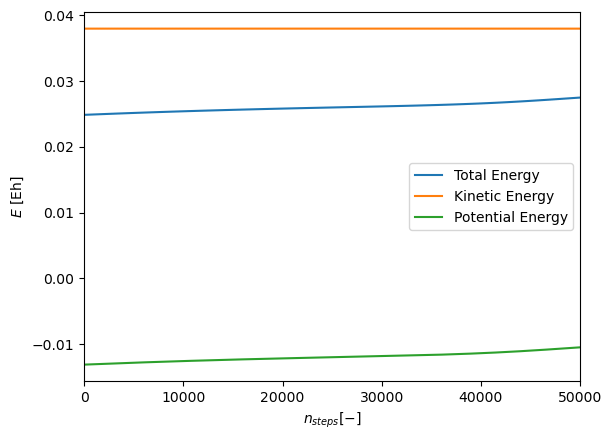

In [13]:
# Energy plot
plt.figure()

plt.plot(e_total_thermo, label = 'Total Energy')
plt.plot(e_kin_thermo, label= 'Kinetic Energy')
plt.plot(e_pot_thermo, label= 'Potential Energy')

plt.xlabel(r'$n_{steps} [-]$')
plt.ylabel(r'$E$ [Eh]')
plt.xlim(0,50000)
plt.legend(loc='center right')

plt.show()

The trajectory from the MD simulation with the thermostat is visualized.

In [ ]:
# Visualization
visualize_trajectory('md_thermostat.npz')